# HS10 Classification Comparison: v1 vs v2

Comparing `hs10_classification_final.csv` (v1, no NAICS) against `hs10_classification_final_v2.csv` (v2, with NAICS codes).

Key questions:
1. Do both versions agree on **High** relevance classifications?
2. Where do they **disagree**?
3. Each file has a different number of HS10 codes — in the **codes unique to each version**, are any rated High?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Load both files
v1 = pd.read_csv(r"c:\github\ai-trade-index\hs10_classification_final.csv", dtype={"hs10_code": str})
v2 = pd.read_csv(r"c:\github\ai-trade-index\hs10_classification_final_v2.csv", dtype={"hs10_code": str})

print(f"v1: {len(v1):,} codes, columns: {list(v1.columns)}")
print(f"v2: {len(v2):,} codes, columns: {list(v2.columns)}")

v1: 19,424 codes, columns: ['relevance', 'confidence', 'primary_category', 'specific_use', 'reasoning', 'hs10_code', 'description']
v2: 18,700 codes, columns: ['relevance', 'confidence', 'primary_category', 'specific_use', 'reasoning', 'hs10_code', 'description', 'naics_code', 'naics_description']


## 1. Basic Overview

In [2]:
RELEVANCE_ORDER = ["Low", "Medium", "High"]

# Counts per relevance level
def relevance_counts(df, label):
    counts = df["relevance"].value_counts()
    total = len(df)
    rows = []
    for r in RELEVANCE_ORDER:
        n = counts.get(r, 0)
        rows.append({"Version": label, "Relevance": r, "Count": n, "Share (%)": round(100 * n / total, 2)})
    return rows

summary = pd.DataFrame(relevance_counts(v1, "v1") + relevance_counts(v2, "v2"))
print(summary.to_string(index=False))

Version Relevance  Count  Share (%)
     v1       Low  16194      83.37
     v1    Medium   2609      13.43
     v1      High    621       3.20
     v2       Low  15538      83.09
     v2    Medium   2518      13.47
     v2      High    644       3.44


## 2. Common vs Unique HS10 Codes

In [2]:
codes_v1 = set(v1["hs10_code"])
codes_v2 = set(v2["hs10_code"])
common_codes = codes_v1 & codes_v2
only_in_v1 = codes_v1 - codes_v2
only_in_v2 = codes_v2 - codes_v1

print(f"Total unique HS10 codes in v1: {len(codes_v1):,}")
print(f"Total unique HS10 codes in v2: {len(codes_v2):,}")
print(f"Common to both:               {len(common_codes):,}")
print(f"Only in v1 (not in v2):       {len(only_in_v1):,}")
print(f"Only in v2 (not in v1):       {len(only_in_v2):,}")

Total unique HS10 codes in v1: 19,424
Total unique HS10 codes in v2: 18,700
Common to both:               18,700
Only in v1 (not in v2):       724
Only in v2 (not in v1):       0


## 3. Agreement on Relevance for Common Codes

In [4]:
# Merge on common codes, compare relevance
v1_common = v1[v1["hs10_code"].isin(common_codes)][["hs10_code", "description", "relevance", "confidence", "primary_category"]].copy()
v2_common = v2[v2["hs10_code"].isin(common_codes)][["hs10_code", "relevance", "confidence", "primary_category"]].copy()

merged = v1_common.merge(v2_common, on="hs10_code", suffixes=("_v1", "_v2"))

# Agreement matrix
agree_mask = merged["relevance_v1"] == merged["relevance_v2"]
print(f"Common codes:         {len(merged):,}")
print(f"Same relevance :      {agree_mask.sum():,} ({100*agree_mask.mean():.1f}%)")
print(f"Different relevance:  {(~agree_mask).sum():,} ({100*(~agree_mask).mean():.1f}%)")
print()

# Crosstab of v1 vs v2 relevance
ct = pd.crosstab(merged["relevance_v1"], merged["relevance_v2"],
                  rownames=["v1 →"], colnames=["v2 ↓"])[RELEVANCE_ORDER].reindex(RELEVANCE_ORDER)
print("Relevance crosstab (v1 rows × v2 columns):")
print(ct)

Common codes:         18,700
Same relevance :      17,825 (95.3%)
Different relevance:  875 (4.7%)

Relevance crosstab (v1 rows × v2 columns):
v2 ↓      Low  Medium  High
v1 →                       
Low     15203     336     6
Medium    331    2099   115
High        4      83   523


## 4. Where do the Two Versions Disagree on "High"?

Cases where one version says High but the other doesn't, and vice versa.

In [5]:
# Both High
both_high = merged[(merged["relevance_v1"] == "High") & (merged["relevance_v2"] == "High")]
# v1 = High, v2 != High
v1_high_only = merged[(merged["relevance_v1"] == "High") & (merged["relevance_v2"] != "High")]
# v2 = High, v1 != High
v2_high_only = merged[(merged["relevance_v1"] != "High") & (merged["relevance_v2"] == "High")]

print(f"Both rate High (agree):           {len(both_high):,}")
print(f"v1=High but v2≠High (v1 only):    {len(v1_high_only):,}")
print(f"v2=High but v1≠High (v2 only):    {len(v2_high_only):,}")

print("\n--- Codes that v1 rates High but v2 does NOT ---")
display(v1_high_only[["hs10_code", "description", "relevance_v1", "relevance_v2", "primary_category_v1", "primary_category_v2"]].reset_index(drop=True))

print("\n--- Codes that v2 rates High but v1 does NOT ---")
display(v2_high_only[["hs10_code", "description", "relevance_v1", "relevance_v2", "primary_category_v1", "primary_category_v2"]].reset_index(drop=True))

Both rate High (agree):           523
v1=High but v2≠High (v1 only):    87
v2=High but v1≠High (v2 only):    121

--- Codes that v1 rates High but v2 does NOT ---


,hs10_code,description,relevance_v1,relevance_v2,primary_category_v1,primary_category_v2
0,2710201002,"FUEL OILS NOS. 2 AND 3, DIESEL, CONTAINING NOT...",High,Medium,Electrical_Power,Electrical_Power
1,2846908075,MIXTURES OF RARE-EARTH CARBONATES OTHER THAN O...,High,Medium,Specialty_Materials,Specialty_Materials
2,2853901000,PHOSPHOR COPPER CONTAINING MORE THAN 15 PERCEN...,High,Medium,Specialty_Materials,Specialty_Materials
3,2903441020,"1,1,1-TRIFLUOROETHANE (HFC-143A)",High,Medium,Cooling_HVAC,Cooling_HVAC
4,2903720100,DICHLOROTRIFLUOROETHANE (HCFC-123),High,Medium,Cooling_HVAC,Cooling_HVAC
...,...,...,...,...,...,...
82,9405426000,LED ELECTRIC LAMPS AND LIGHTING FITTINGS BASE ...,High,Medium,Electrical_Power,Electrical_Power
83,9801001043,U.S. GOODS IN HEADINGS 8469-8473 THAT ARE RETU...,High,Medium,Compute_Hardware,Compute_Hardware
84,9801001049,U.S. GOODS PROVIDED IN HEADINGS 8501-8503 THAT...,High,Medium,Electrical_Power,Electrical_Power
85,9801001051,U.S. GOODS PROVIDED FOR IN HEADING 8504 THAT A...,High,Medium,Electrical_Power,Electrical_Power



--- Codes that v2 rates High but v1 does NOT ---


,hs10_code,description,relevance_v1,relevance_v2,primary_category_v1,primary_category_v2
0,2517100055,"CRUSHED OR BROKEN STONE, USED FOR CONCRETE AGG...",Medium,High,Building_Structure,Building_Structure
1,2523290000,PORTLAND CEMENT NESOI,Medium,High,Building_Structure,Building_Structure
2,2710190615,NO. 4-TYPE FUEL OILS CONTAINING MORE THAN 500 ...,Medium,High,Electrical_Power,Electrical_Power
3,2710190630,FUEL OIL NO. 6 (SAYBOLT UNIV VISCOSITY AT 37.8...,Medium,High,Electrical_Power,Electrical_Power
4,2710190650,DISTILLATE AND RESIDUAL FUEL OILS (INCLUDING B...,Medium,High,Electrical_Power,Electrical_Power
...,...,...,...,...,...,...
116,9032906180,PARTS AND ACCESSORIES OF AUTOMATIC REGULATING ...,Medium,High,Electrical_Power,Cooling_HVAC
117,9107008000,TIME SWITCHES WITH CLOCKS OR WATCH MOVEMENT OR...,Medium,High,Electrical_Power,Electrical_Power
118,9403999020,WELDED WIRE RACK DECKING WHETHER OR NOT GALVAN...,Medium,High,Building_Structure,Building_Structure
119,9405428200,"LED BACKLGHTS MDLS, LGHTING SRCES CNSIST 1/MOR...",Low,High,Not_DC_Related,Compute_Hardware


## 5. Codes Unique to Each Version

v1 has 19,424 codes; v2 has 18,700. Codes present in only one version may still contain High-relevance items worth noting.

In [6]:
# Codes only in v1
df_only_v1 = v1[v1["hs10_code"].isin(only_in_v1)].copy()
df_only_v2 = v2[v2["hs10_code"].isin(only_in_v2)].copy()

print("=== Codes ONLY in v1 ===")
print(f"Total: {len(df_only_v1):,}")
print(df_only_v1["relevance"].value_counts().reindex(RELEVANCE_ORDER).fillna(0).astype(int).to_string())

print("\n=== Codes ONLY in v2 ===")
print(f"Total: {len(df_only_v2):,}")
print(df_only_v2["relevance"].value_counts().reindex(RELEVANCE_ORDER).fillna(0).astype(int).to_string())

high_only_v1 = df_only_v1[df_only_v1["relevance"] == "High"]
high_only_v2 = df_only_v2[df_only_v2["relevance"] == "High"]

print(f"\nHigh-relevance codes exclusive to v1: {len(high_only_v1):,}")
print(f"High-relevance codes exclusive to v2: {len(high_only_v2):,}")

=== Codes ONLY in v1 ===
Total: 724
relevance
Low       649
Medium     64
High       11

=== Codes ONLY in v2 ===
Total: 0
relevance
Low       0
Medium    0
High      0

High-relevance codes exclusive to v1: 11
High-relevance codes exclusive to v2: 0


In [7]:
show_cols_v1 = ["hs10_code", "description", "relevance", "confidence", "primary_category"]
show_cols_v2 = ["hs10_code", "description", "relevance", "confidence", "primary_category", "naics_code", "naics_description"]

print("High-relevance codes that appear ONLY in v1:")
display(high_only_v1[show_cols_v1].reset_index(drop=True))

print("\nHigh-relevance codes that appear ONLY in v2:")
display(high_only_v2[show_cols_v2].reset_index(drop=True))

High-relevance codes that appear ONLY in v1:


,hs10_code,description,relevance,confidence,primary_category
0,2903441030,"1,1,2-TRIFLUOROETHANE (HFC-143)",High,90,Cooling_HVAC
1,3801105010,"ARTIFICIAL GRAPHITE, SURFACE-MOLDED SPHERICAL ...",High,85,Specialty_Materials
2,3818000020,"CHMCL ELMNTS DOPED FOR USE IN ELCTRNCS,DISCS/W...",High,95,Compute_Hardware
3,3818000030,"CHMCL ELMNTS DOPED FOR USE IN ELCTRNCS,DISCS/W...",High,95,Compute_Hardware
4,3818000095,OTHER CHEMICAL ELEMENTS DOPED FOR USE IN ELECT...,High,95,Compute_Hardware
5,3824993910,"MIXTURES OF TWO OR MORE INORGANIC COMPOUNDS, O...",High,90,Electrical_Power
6,3827510000,MIXTURES CONTAINING TRIFLUOROMETHANE (HFC-23),High,95,Cooling_HVAC
7,8501640135,"AC GENERATORS (ALTERNATORS), OUTPUT EXCEEDING ...",High,95,Electrical_Power
8,8501640155,"AC GENERATORS (ALTERNATORS), OUTPUT EXCEEDING ...",High,95,Electrical_Power
9,8542390070,ELECTRONIC INTEGRATED CIRCUITS WITH ADJUSTABLE...,High,90,Compute_Hardware



High-relevance codes that appear ONLY in v2:


,hs10_code,description,relevance,confidence,primary_category,naics_code,naics_description


## 6. Visualisations

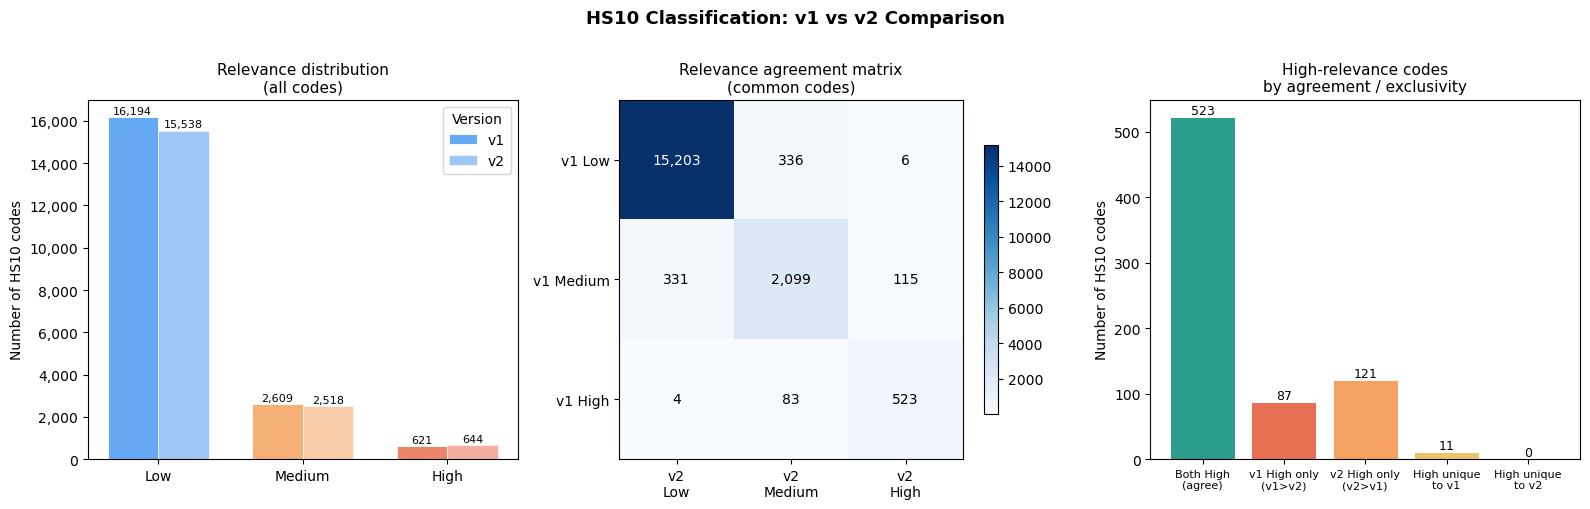

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {"Low": "#4e9af1", "Medium": "#f4a261", "High": "#e76f51"}

# ── Plot 1: Relevance distribution side-by-side bar chart ──────────────────
ax = axes[0]
x = np.arange(len(RELEVANCE_ORDER))
width = 0.35
for i, (label, df) in enumerate([("v1", v1), ("v2", v2)]):
    counts = [df["relevance"].value_counts().get(r, 0) for r in RELEVANCE_ORDER]
    bars = ax.bar(x + i * width, counts, width, label=label,
                  color=[colors[r] for r in RELEVANCE_ORDER], alpha=0.85 if i == 0 else 0.55,
                  edgecolor="white", linewidth=0.7)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
                f"{cnt:,}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(RELEVANCE_ORDER)
ax.set_title("Relevance distribution\n(all codes)", fontsize=11)
ax.set_ylabel("Number of HS10 codes")
ax.legend(title="Version")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

# ── Plot 2: Heatmap / confusion matrix of relevance agreement ───────────────
ax = axes[1]
ct_vals = pd.crosstab(merged["relevance_v1"], merged["relevance_v2"]
                       )[RELEVANCE_ORDER].reindex(RELEVANCE_ORDER).fillna(0)
im = ax.imshow(ct_vals.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(RELEVANCE_ORDER)))
ax.set_yticks(range(len(RELEVANCE_ORDER)))
ax.set_xticklabels([f"v2\n{r}" for r in RELEVANCE_ORDER])
ax.set_yticklabels([f"v1 {r}" for r in RELEVANCE_ORDER])
for i in range(len(RELEVANCE_ORDER)):
    for j in range(len(RELEVANCE_ORDER)):
        val = int(ct_vals.values[i, j])
        ax.text(j, i, f"{val:,}", ha="center", va="center",
                color="white" if val > ct_vals.values.max() * 0.5 else "black", fontsize=10)
ax.set_title("Relevance agreement matrix\n(common codes)", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.75)

# ── Plot 3: High-relevance breakdown — common vs unique ─────────────────────
ax = axes[2]
groups = ["Both High\n(agree)", "v1 High only\n(v1>v2)", "v2 High only\n(v2>v1)",
          "High unique\nto v1", "High unique\nto v2"]
values = [len(both_high), len(v1_high_only), len(v2_high_only),
          len(high_only_v1), len(high_only_v2)]
bar_colors = ["#2a9d8f", "#e76f51", "#f4a261", "#e9c46a", "#264653"]
bars = ax.bar(groups, values, color=bar_colors, edgecolor="white", linewidth=0.7)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=9)
ax.set_title("High-relevance codes\nby agreement / exclusivity", fontsize=11)
ax.set_ylabel("Number of HS10 codes")
ax.tick_params(axis="x", labelsize=8)

plt.suptitle("HS10 Classification: v1 vs v2 Comparison", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Primary Category Breakdown for High-Relevance Codes

High-relevance counts by primary_category:

                         v1   v2
primary_category                
Electrical_Power        246  257
Compute_Hardware        153  158
Cooling_HVAC            134  135
Building_Structure       29   44
Networking_Telecom       27   24
Specialty_Materials      22   18
Fire_Safety_Security      9    8
Maintenance_Operations    1    0


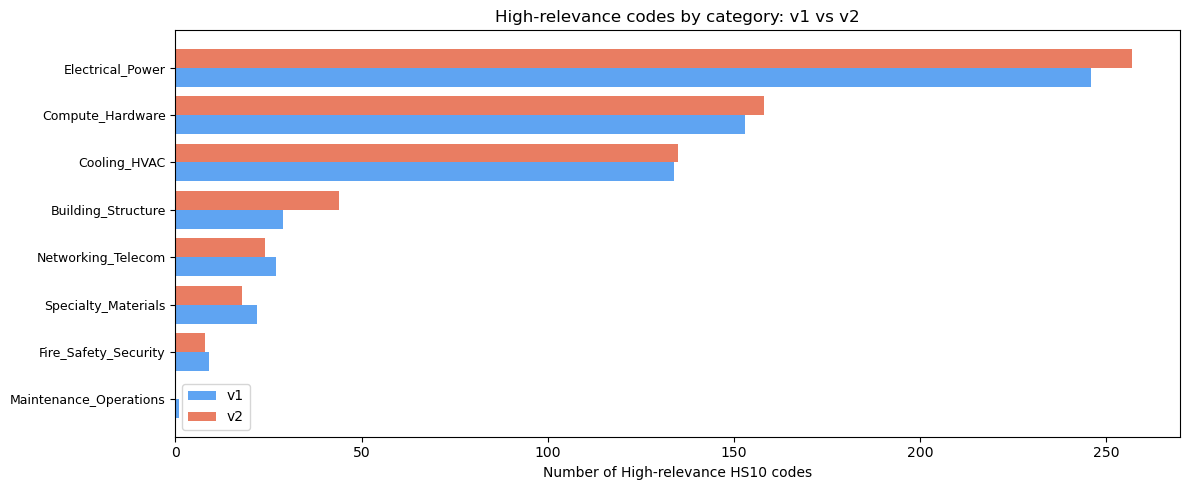

In [13]:
high_v1 = v1[v1["relevance"] == "High"]
high_v2 = v2[v2["relevance"] == "High"]

cat_v1 = high_v1["primary_category"].value_counts().rename("v1")
cat_v2 = high_v2["primary_category"].value_counts().rename("v2")
cat_comp = pd.concat([cat_v1, cat_v2], axis=1).fillna(0).astype(int).sort_values("v1", ascending=False)

print("High-relevance counts by primary_category:\n")
print(cat_comp.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
ind = np.arange(len(cat_comp))
w = 0.4
ax.barh(ind + w/2, cat_comp["v1"], w, label="v1", color="#4e9af1", alpha=0.9)
ax.barh(ind - w/2, cat_comp["v2"], w, label="v2", color="#e76f51", alpha=0.9)
ax.set_yticks(ind)
ax.set_yticklabels(cat_comp.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Number of High-relevance HS10 codes")
ax.set_title("High-relevance codes by category: v1 vs v2")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout()
plt.show()

## 8. Summary Table

Consolidated view of all comparison metrics.

In [14]:
summary_data = {
    "Metric": [
        "Total HS10 codes",
        "  — Low relevance",
        "  — Medium relevance",
        "  — High relevance",
        "Codes in common with other version",
        "  — Agree on same relevance level",
        "  — Disagree on relevance level",
        "High: both agree (same code, both High)",
        "High: v1 only (code shared, v1=High v2≠High)",
        "High: v2 only (code shared, v2=High v1≠High)",
        "Codes EXCLUSIVE to this version",
        "  — Exclusive codes rated High",
    ],
    "v1": [
        len(v1), len(v1[v1.relevance=="Low"]), len(v1[v1.relevance=="Medium"]), len(v1[v1.relevance=="High"]),
        len(common_codes), agree_mask.sum(), (~agree_mask).sum(),
        len(both_high), len(v1_high_only), len(v2_high_only),
        len(only_in_v1), len(high_only_v1),
    ],
    "v2": [
        len(v2), len(v2[v2.relevance=="Low"]), len(v2[v2.relevance=="Medium"]), len(v2[v2.relevance=="High"]),
        len(common_codes), agree_mask.sum(), (~agree_mask).sum(),
        len(both_high), len(v1_high_only), len(v2_high_only),
        len(only_in_v2), len(high_only_v2),
    ],
}

df_summary = pd.DataFrame(summary_data)
display(df_summary.to_string(index=False))

'                                      Metric    v1    v2\n                            Total HS10 codes 19424 18700\n                             — Low relevance 16194 15538\n                          — Medium relevance  2609  2518\n                            — High relevance   621   644\n          Codes in common with other version 18700 18700\n             — Agree on same relevance level 17825 17825\n               — Disagree on relevance level   875   875\n     High: both agree (same code, both High)   523   523\nHigh: v1 only (code shared, v1=High v2≠High)    87    87\nHigh: v2 only (code shared, v2=High v1≠High)   121   121\n             Codes EXCLUSIVE to this version   724     0\n                — Exclusive codes rated High    11     0'

In [12]:
df_summary

,Metric,v1,v2
0,Total HS10 codes,19424,18700
1,— Low relevance,16194,15538
2,— Medium relevance,2609,2518
3,— High relevance,621,644
4,Codes in common with other version,18700,18700
5,— Agree on same relevance level,17825,17825
6,— Disagree on relevance level,875,875
7,"High: both agree (same code, both High)",523,523
8,"High: v1 only (code shared, v1=High v2≠High)",87,87
9,"High: v2 only (code shared, v2=High v1≠High)",121,121


In [15]:
df = pd.read_parquet('TOTALdata-current.parquet')

df.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]
df["HS4"] = df["HS10"].str[0:4]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["imports"] = df["CON_VAL_MO"].astype(float)

df["duty"] = df["CAL_DUT_MO"].astype(float)

df.rename({"I_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

## 9. Trade Value of High-Relevance Disagreements

For codes rated High by at least one version, how much import value sits in the **agree** bucket vs the **disagree** buckets?

In [18]:
# Aggregate total imports per HS10 across all time periods
# df["HS10"] is int64; classification hs10_code is string — align types
trade_agg = df.groupby("HS10")["imports"].sum().reset_index()
trade_agg["hs10_code"] = trade_agg["HS10"].astype(str)

# Label every row in the merged (common-codes) dataframe by its High-agreement category
def high_bucket(row):
    v1r, v2r = row["relevance_v1"], row["relevance_v2"]
    if v1r == "High" and v2r == "High":
        return "Both High (agree)"
    elif v1r == "High":
        return "v1 High only (disagree)"
    elif v2r == "High":
        return "v2 High only (disagree)"
    else:
        return "Neither High"

merged_trade = merged.copy()
merged_trade["high_bucket"] = merged_trade.apply(high_bucket, axis=1)

# Also tag codes exclusive to v1 that are rated High
excl_v1_trade = high_only_v1[["hs10_code", "description"]].copy()
excl_v1_trade["high_bucket"] = "v1 exclusive High"

# Join trade values onto merged codes
merged_trade = merged_trade.merge(trade_agg[["hs10_code", "imports"]], on="hs10_code", how="left")
excl_v1_trade = excl_v1_trade.merge(trade_agg[["hs10_code", "imports"]], on="hs10_code", how="left")

# Combine for a full picture of all "High in at least one version" codes
high_any = pd.concat([
    merged_trade[merged_trade["high_bucket"] != "Neither High"][["hs10_code", "description", "high_bucket", "imports"]],
    excl_v1_trade[["hs10_code", "description", "high_bucket", "imports"]],
], ignore_index=True)

# Sum trade by bucket
bucket_trade = (
    high_any.groupby("high_bucket")["imports"]
    .agg(total_imports="sum", n_codes="count")
    .reset_index()
)
bucket_trade["share_of_high_trade_pct"] = 100 * bucket_trade["total_imports"] / bucket_trade["total_imports"].sum()
bucket_trade["total_imports_bn"] = bucket_trade["total_imports"] / 1e9
bucket_trade = bucket_trade.sort_values("total_imports", ascending=False)

print("Trade value breakdown for High-relevance HS10 codes (all time, excl. HS2 27/71/98/99):\n")
print(bucket_trade[["high_bucket", "n_codes", "total_imports_bn", "share_of_high_trade_pct"]]
      .rename(columns={"high_bucket": "Bucket", "n_codes": "# codes",
                        "total_imports_bn": "Imports ($bn)", "share_of_high_trade_pct": "Share of High-trade (%)"})
      .to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

Trade value breakdown for High-relevance HS10 codes (all time, excl. HS2 27/71/98/99):

                 Bucket  # codes  Imports ($bn)  Share of High-trade (%)
      Both High (agree)      520       3,538.77                    87.96
v2 High only (disagree)      114         283.62                     7.05
v1 High only (disagree)       81         196.11                     4.87
      v1 exclusive High       11           4.62                     0.11


In [20]:
df.tail()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty
2710069,TOTAL FOR ALL COUNTRIES,2424818,373603,8448205090,PTS & ACCESS OF MACH OF HEAD 8444 OR THEIR AUX...,2025-12-01,HS10,84,8448,2424818.0,373603.0
2710070,TOTAL FOR ALL COUNTRIES,1096066,183098,8448310000,CARD CLOTHING,2025-12-01,HS10,84,8448,1096066.0,183098.0
2710071,TOTAL FOR ALL COUNTRIES,132714,27857,8448320010,PARTS OF COTTON GINS,2025-12-01,HS10,84,8448,132714.0,27857.0
2710072,TOTAL FOR ALL COUNTRIES,1160979,216099,8448320090,"PTS OF MACH FOR PREPAR TEXTILE FIBRS,NESOI",2025-12-01,HS10,84,8448,1160979.0,216099.0
2710073,TOTAL FOR ALL COUNTRIES,282439,49934,8448330000,"SPINDLES,SPIN FLYERS,SPIN RINGS & RING TRAVELLERS",2025-12-01,HS10,84,8448,282439.0,49934.0


In [15]:
# All codes v1 puts in Specialty_Materials (any relevance level)
sm_v1 = v1[v1["primary_category"] == "Specialty_Materials"][
    ["hs10_code", "description", "relevance", "confidence", "primary_category"]
].copy()

# Look up those same codes in v2 — do NOT pre-filter v2 by category,
# so we correctly capture codes v2 reclassified into a different category
sm_v2_lookup = v2.set_index("hs10_code")[["relevance", "confidence", "primary_category"]].rename(
    columns={"relevance": "relevance_v2", "confidence": "confidence_v2", "primary_category": "primary_category_v2"}
)

sm = sm_v1.rename(columns={
    "relevance": "relevance_v1",
    "confidence": "confidence_v1",
    "primary_category": "primary_category_v1",
})
sm = sm.join(sm_v2_lookup, on="hs10_code", how="left")

# Keep only codes rated High in at least one version
sm = sm[(sm["relevance_v1"] == "High") | (sm["relevance_v2"] == "High")]
sm = sm.sort_values(["relevance_v1", "hs10_code"], ascending=[False, True])

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)
display(sm[["hs10_code", "description",
            "relevance_v1", "primary_category_v1", "confidence_v1",
            "relevance_v2", "primary_category_v2", "confidence_v2"]].reset_index(drop=True))

,hs10_code,description,relevance_v1,primary_category_v1,confidence_v1,relevance_v2,primary_category_v2,confidence_v2
0,2804695000,SILICON LESS THAN 99 PERCENT PURE,Medium,Specialty_Materials,75,High,Specialty_Materials,85.0
1,2833240000,NICKEL SULFATE,Medium,Specialty_Materials,75,High,Electrical_Power,85.0
2,2846902082,RARE EARTH CHLORIDES MIXTURES EXCEPT CERIUM CHLORIDES CONTAINING YTTRIUM OR SCANDIUM AS THE PREDOMINANT METAL,Medium,Specialty_Materials,85,High,Specialty_Materials,90.0
3,7409400000,"PLATES, SHEET AND STRIP OF CU-NCKL BASE ALLOYS (CUPRO-NICKEL) OR COPPER-NICKEL-ZINC BASE ALLOYS (NICKEL SILVER)",Medium,Specialty_Materials,75,High,Electrical_Power,85.0
4,8112999100,"WROUGHT ARTICLES OF GALLIUM, INDIUM, NIOBIUM, ARTICLES THEREOF, NESOI",Medium,Specialty_Materials,75,High,Specialty_Materials,85.0
5,8543901200,"PHYSICAL VAPOR DEPOSITION (PVD) PARTS, NESOI",Medium,Specialty_Materials,75,High,Compute_Hardware,90.0
6,2615903000,SYNTHETIC TANTALUM-NIOBIUM(COLUMBIUM) CONCENTRATES,High,Specialty_Materials,85,High,Specialty_Materials,90.0
7,2805300020,"NEODYMIUM, NOT INTERMIXED OR INTERALLOYED",High,Specialty_Materials,90,High,Specialty_Materials,95.0
8,2805300050,"RARE EARTH METALS NESOI, SCANDIUM AND YTTRIUM, NOT INTERMIXED OR INTERALLOYED",High,Specialty_Materials,95,High,Specialty_Materials,95.0
9,2805300090,"RARE EARTH METALS NESOI, SCANDIUM AND YTTRIUM, INTERMIXED OR INTERALLOYED",High,Specialty_Materials,95,High,Specialty_Materials,95.0


## Build v3: v2 as Baseline + v1-only Codes Appended

**Logic:**  
- All 18,700 codes from v2 are kept as-is (NAICS-informed classifications are the canonical source).  
- The 724 codes present in v1 but absent from v2 are appended, taking their classifications from v1.  
- Result: a complete, gap-free classification covering all codes seen in either version.

In [3]:
# v2 is the baseline — keep all its rows exactly as-is
v3 = v2.copy()

# Identify the 724 codes in v1 that are missing from v2
v1_only = v1[v1["hs10_code"].isin(only_in_v1)].copy()

# v1 lacks naics_code / naics_description columns — add them as NaN to align schemas
for col in ["naics_code", "naics_description"]:
    if col not in v1_only.columns:
        v1_only[col] = pd.NA

# Append to form v3 (column order matches v2)
v3 = pd.concat([v3, v1_only[v3.columns]], ignore_index=True)

print(f"v2 rows:          {len(v2):,}")
print(f"v1-only appended: {len(v1_only):,}  (of which High: {(v1_only['relevance']=='High').sum()})")
print(f"v3 total rows:    {len(v3):,}")
print(f"\nv3 relevance distribution:")
print(v3["relevance"].value_counts().reindex(["Low", "Medium", "High"]).to_string())

v2 rows:          18,700
v1-only appended: 724  (of which High: 11)
v3 total rows:    19,424

v3 relevance distribution:
relevance
Low       16187
Medium     2582
High        655


In [4]:
out_path = r"c:\github\ai-trade-index\hs10_classification_final_v3.csv"
v3.to_csv(out_path, index=False)
print(f"Saved v3 → {out_path}")

Saved v3 → c:\github\ai-trade-index\hs10_classification_final_v3.csv


In [17]:
v2[v2["hs10_code"] == "7403290180"]

,relevance,confidence,primary_category,specific_use,reasoning,hs10_code,description,naics_code,naics_description
13369,High,85,Electrical_Power,"Raw material for electrical conductors, busbars, and power distribution components","Unwrought copper alloys are essential raw materials for data center electrical infrastructure. Copper's excellent conductivity makes it critical for power distribution systems, busbars, electrical cables, and grounding systems. The NAICS code confirms this is from nonferrous metal production, indicating industrial-grade material suitable for electrical applications.",7403290180,"UNWROUGHT COPPER ALLOYS, NESOI",331410,NONFERROUS METAL (EXCEPT ALUMINUM) SMELTED OR REFINED


In [7]:
v3.head()

,relevance,confidence,primary_category,specific_use,reasoning,hs10_code,description,naics_code,naics_description
0,Low,100,Not_DC_Related,No application in data center context,Live purebred breeding horses are livestock us...,101210010,"HORSES, LIVE, PUREBRED BREEDING MALE",112920,HORSES AND OTHER EQUINE
1,Low,100,Not_DC_Related,Not applicable to data center construction or ...,Live horses are livestock animals with no conn...,101210020,"HORSES, LIVE, PUREBRED BREEDING FEMALE",112920,HORSES AND OTHER EQUINE
2,Low,100,Not_DC_Related,No application in data center construction or ...,Live horses are livestock animals with no rele...,101290090,"HORSES, LIVE, NESOI",112920,HORSES AND OTHER EQUINE
3,Low,100,Not_DC_Related,Not applicable - livestock animals have no rol...,Live donkeys/asses are livestock animals used ...,101300000,"ASSES, LIVE",112920,HORSES AND OTHER EQUINE
4,Low,100,Not_DC_Related,Not applicable to data center operations,Live cattle are agricultural livestock with no...,102210010,"CATTLE, LIVE, PUREBRED BREEDING MALE, DAIRY",11211X,Description not found for NAICS 11211X
